# Trabalho 1 de Bioinformática

Seguimos a metodologia de **Millán Arias et al. (2023)** para investigar se o ambiente influencia mais a assinatura genômica do que a taxonomia em procariotos extremófilos.

> Millán Arias P et al. *Environment and taxonomy shape the genomic signature of prokaryotic extremophiles.* Sci Rep. 2023;13:16105. https://doi.org/10.1038/s41598-023-42518-y

## Organismos selecionados

Os 8 organismos foram extraídos do **Supplementary Table S1** do artigo. A seleção foi feita escolhendo um representante de cada domínio (Bacteria, Archaea) para cada categoria ambiental, permitindo comparar organismos filogeneticamente distantes que habitam o mesmo ambiente.

Para acessar um genoma no NCBI: `https://www.ncbi.nlm.nih.gov/datasets/genome/{ACCESSION}/`


| Ambiente | OGT | Organismo | Domínio | Accession |
|---|---|---|---|---|
| Hipertermófilo | > 80°C | *Thermocrinis ruber* | Bacteria | [GCA_000512735.1](https://www.ncbi.nlm.nih.gov/datasets/genome/GCA_000512735.1/) |
| Hipertermófilo | > 80°C | *Thermotoga maritima* | Bacteria | [GCA_000008545.1](https://www.ncbi.nlm.nih.gov/datasets/genome/GCA_000008545.1/) |
| Hipertermófilo | > 80°C | *Pyrococcus furiosus* | Archaea | [GCA_000007305.1](https://www.ncbi.nlm.nih.gov/datasets/genome/GCA_000007305.1/) |
| Hipertermófilo | > 80°C | *Thermococcus litoralis* | Archaea | [GCA_000246985.3](https://www.ncbi.nlm.nih.gov/datasets/genome/GCA_000246985.3/) |
| Mesófilo | 20–45°C | *Escherichia fergusonii* | Bacteria | [GCA_000026225.1](https://www.ncbi.nlm.nih.gov/datasets/genome/GCA_000026225.1/) |
| Mesófilo | 20–45°C | *Methanococcus maripaludis* | Archaea | [GCA_002945325.1](https://www.ncbi.nlm.nih.gov/datasets/genome/GCA_002945325.1/) |
| Psicrófilo | < 20°C | *Psychrobacter arcticus* | Bacteria | [GCA_000012305.1](https://www.ncbi.nlm.nih.gov/datasets/genome/GCA_000012305.1/) |
| Psicrófilo | < 20°C | *Methanococcoides burtonii* | Archaea | [GCA_000013725.1](https://www.ncbi.nlm.nih.gov/datasets/genome/GCA_000013725.1/) |


> *T. ruber* e *P. furiosus* são os exemplares identificados pelo artigo como casos em que a assinatura ambiental supera a taxonômica: agrupados juntos por todos os algoritmos de clustering apesar de pertencerem a domínios opostos da Árvore da Vida.

In [14]:
import os
import gzip
import shutil
import urllib.request
from collections import defaultdict
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.decomposition import PCA
from scipy.spatial.distance import pdist, cdist, squareform

# configurações globais de visualização
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')

# pastas de saída
os.makedirs('genomas',    exist_ok=True)
os.makedirs('resultados', exist_ok=True)

print('imports ok')

imports ok


## 2. Definição dos Organismos

8 organismos distribuídos em 3 ambientes × 2 domínios.
Accessions retirados da **Tabela S1 do Artigo**.


In [ ]:
ORGANISMOS = {
    # hipertermófilos
    'T. ruber': {
        'accession'     : 'GCA_000512735.1',
        'nome_completo' : 'Thermocrinis ruber',
        'dominio'       : 'Bacteria',
        'ambiente'      : 'Hipertermófilo',
    },
    'T. maritima': {
        'accession'     : 'GCA_000008545.1',
        'nome_completo' : 'Thermotoga maritima',
        'dominio'       : 'Bacteria',
        'ambiente'      : 'Hipertermófilo',
    },
    'P. furiosus': {
        'accession'     : 'GCA_000007305.1',
        'nome_completo' : 'Pyrococcus furiosus',
        'dominio'       : 'Archaea',
        'ambiente'      : 'Hipertermófilo',
    },
    'T. litoralis': {
        'accession'     : 'GCA_000246985.3',
        'nome_completo' : 'Thermococcus litoralis',
        'dominio'       : 'Archaea',
        'ambiente'      : 'Hipertermófilo',
    },
    # mesófilos
    'E. fergusonii': {
        'accession'     : 'GCA_000026225.1',
        'nome_completo' : 'Escherichia fergusonii',
        'dominio'       : 'Bacteria',
        'ambiente'      : 'Mesófilo',
    },
    'M. maripaludis': {
        'accession'     : 'GCA_002945325.1',
        'nome_completo' : 'Methanococcus maripaludis',
        'dominio'       : 'Archaea',
        'ambiente'      : 'Mesófilo',
    },
    # psicrófilos
    'P. arcticus': {
        'accession'     : 'GCA_000012305.1',
        'nome_completo' : 'Psychrobacter arcticus',
        'dominio'       : 'Bacteria',
        'ambiente'      : 'Psicrófilo',
    },
    'M. burtonii': {
        'accession'     : 'GCA_000013725.1',
        'nome_completo' : 'Methanococcoides burtonii',
        'dominio'       : 'Archaea',
        'ambiente'      : 'Psicrófilo',
    },
}

# tamanhos de fragmento a testar além dos 500 kbp do artigo
TAMANHOS_FRAGMENTO = [500_000, 1_000_000, 1_500_000]  # 500 kbp, 1 Mbp, 1.5 Mbp

print('organismos definidos:')
for nome, info in ORGANISMOS.items():
    print(f'  {nome:18s} | {info["dominio"]:8s} | {info["ambiente"]:15s} | {info["accession"]}')

organismos definidos:
  T. ruber           | Bacteria | Hipertermófilo  | GCA_000512735.1
  T. maritima        | Bacteria | Hipertermófilo  | GCA_000008545.1
  P. furiosus        | Archaea  | Hipertermófilo  | GCA_000007305.1
  T. litoralis       | Archaea  | Hipertermófilo  | GCA_000246985.3
  E. fergusonii      | Bacteria | Mesófilo        | GCA_000026225.1
  M. maripaludis     | Archaea  | Mesófilo        | GCA_002945325.1
  P. arcticus        | Bacteria | Psicrófilo      | GCA_000012305.1
  M. burtonii        | Archaea  | Psicrófilo      | GCA_000013725.1


## 3. Download dos Genomas

Download direto do FTP do NCBI.

> Se preferir baixar manualmente: `ncbi.nlm.nih.gov/datasets/genome/<accession>`,
> clicar em Download - Genome sequences (FASTA) - salvar na pasta `genomas/`


In [ ]:
def montar_url_ftp(accession):
    # extrai o prefixo (GCA ou GCF) e os números do accession
    # para montar o caminho de pastas do FTP do NCBI
    prefixo = accession[:3]
    numeros = accession[4:13]
    p1, p2, p3 = numeros[:3], numeros[3:6], numeros[6:9]
    base = f'https://ftp.ncbi.nlm.nih.gov/genomes/all/{prefixo}/{p1}/{p2}/{p3}/'
    return base

def encontrar_url_fna(accession):
    import urllib.request
    import re

    # acessa a pasta do accession no FTP e busca o nome da subpasta
    base = montar_url_ftp(accession)
    try:
        with urllib.request.urlopen(base) as resp:
            html = resp.read().decode()
        pastas = re.findall(rf'href="({accession}[^"]+/)"', html)
        if not pastas:
            return None
        # monta a URL completa do arquivo .fna.gz
        pasta = pastas[0]
        url_fna = base + pasta + pasta.rstrip('/') + '_genomic.fna.gz'
        return url_fna
    except Exception as e:
        print(f'erro ao buscar URL: {e}')
        return None

def baixar_genoma(nome, accession):
    arquivo_fna = f'genomas/{nome.replace(" ", "_").replace(".", "")}.fna'
    arquivo_gz  = arquivo_fna + '.gz'

    # se o arquivo já existe, não baixa novamente
    if os.path.exists(arquivo_fna):
        tamanho = os.path.getsize(arquivo_fna) / 1e6
        print(f'{nome} ({tamanho:.1f} MB)')
        return arquivo_fna

    url = encontrar_url_fna(accession)
    if not url:
        print(f'nao encontrou URL para {accession}')
        return None

    print(f'baixando {nome}...', end=' ', flush=True)
    try:
        # baixa o arquivo comprimido, descompacta e remove o .gz
        urllib.request.urlretrieve(url, arquivo_gz)
        with gzip.open(arquivo_gz, 'rb') as f_in:
            with open(arquivo_fna, 'wb') as f_out:
                shutil.copyfileobj(f_in, f_out)
        os.remove(arquivo_gz)
        tamanho = os.path.getsize(arquivo_fna) / 1e6
        print(f'ok ({tamanho:.1f} MB)')
        return arquivo_fna
    except Exception as e:
        print(f'erro: {e}')
        return None

# baixa os genomas de todos os organismos definidos
ARQUIVOS = {}
print('baixando genomas do NCBI...')
for nome, info in ORGANISMOS.items():
    arq = baixar_genoma(nome, info['accession'])
    ARQUIVOS[nome] = arq

disponiveis = sum(1 for v in ARQUIVOS.values() if v)
print(f'\n{disponiveis}/{len(ORGANISMOS)} genomas disponíveis')

baixando genomas do NCBI...
baixando T. ruber... ok (1.5 MB)
baixando T. maritima... ok (1.9 MB)
baixando P. furiosus... ok (1.9 MB)
baixando T. litoralis... ok (2.2 MB)
baixando E. fergusonii... ok (4.7 MB)
baixando M. maripaludis... ok (1.7 MB)
baixando P. arcticus... ok (2.7 MB)
baixando M. burtonii... ok (2.6 MB)

8/8 genomas disponíveis


In [ ]:
# verifica quantas sequências cada genoma tem e qual caso da metodologia se aplica
def checar_contigs(arquivos):
    for nome, arq in arquivos.items():
        if not arq or not os.path.exists(arq):
            continue

        # lê o tamanho de cada sequência no arquivo FASTA
        tamanhos = []
        seq = []
        with open(arq) as f:
            for linha in f:
                if linha.startswith('>'):
                    if seq:
                        tamanhos.append(len(''.join(seq)))
                    seq = []
                else:
                    seq.append(linha.strip())
            if seq:
                tamanhos.append(len(''.join(seq)))

        # ordena do maior para o menor
        tamanhos.sort(reverse=True)
        n = len(tamanhos)
        maior = tamanhos[0]

        # define qual caso da metodologia se aplica
        if n == 1 and maior >= 500_000:
            status = 'maior que 500kbp (seleciona fragmento aleatorio dentro do contig)'
        elif n > 1 and maior >= 500_000:
            status = f'maior contig > 500kbp (seleciona fragmento aleatorio)'
        else:
            status = f'precisa concatenar (nenhum contig isolado atinge 500kbp)'

        tamanhos_str = ' + '.join(f'{t/1e6:.2f}Mb' for t in tamanhos)
        print(f'{nome:<25} [{tamanhos_str}]  {status}')

checar_contigs(ARQUIVOS)

T. ruber                  [1.52Mb]  maior que 500kbp (seleciona fragmento aleatorio dentro do contig)
T. maritima               [1.86Mb]  maior que 500kbp (seleciona fragmento aleatorio dentro do contig)
P. furiosus               [1.91Mb]  maior que 500kbp (seleciona fragmento aleatorio dentro do contig)
T. litoralis              [2.22Mb]  maior que 500kbp (seleciona fragmento aleatorio dentro do contig)
E. fergusonii             [4.59Mb + 0.06Mb]  maior contig > 500kbp (seleciona fragmento aleatorio)
M. maripaludis            [1.71Mb]  maior que 500kbp (seleciona fragmento aleatorio dentro do contig)
P. arcticus               [2.65Mb]  maior que 500kbp (seleciona fragmento aleatorio dentro do contig)
M. burtonii               [2.58Mb]  maior que 500kbp (seleciona fragmento aleatorio dentro do contig)


### Extração do fragmento e cálculo dos k-mers

Seguindo a metodologia do artigo, cada genoma é representado por um único fragmento de DNA de tamanho fixo,
extraído do maior contig da montagem. O fragmento é selecionado aleatoriamente dentro do contig (seed=42
para reprodutibilidade). Se nenhum contig individual atingir o tamanho necessário, os contigs são concatenados
com separador N até completar o tamanho (k-mers que acabam "cruzando" essas junções são descartados)

Para cada fragmento, é calculado o vetor de frequências de k-mers canônicos: a janela deslizante percorre
a sequência original e seu complemento reverso, contando cada k-mer apenas na sua forma canônica
(o menor entre o k-mer e seu reverso complementar em ordem alfabética). Isso elimina a redundância entre
fitas e garante que o vetor seja independente da orientação do arquivo FASTA.

### O experimento testa

**Três tamanhos de fragmento:**
- 500 kbp (padrão do artigo)
- 1 Mbp
- 1.5 Mbp

**Oito valores de k (1 a 8)**, resultando em vetores de 2 a 32.896 dimensões.
Os valores k=7 e k=8 foram adicionados (o artigo testa ate 6)

Obs: O número de dimensões do vetor cresce com k seguindo o número de k-mers canônicos
possíveis: k=1 gera 2 dimensões, k=6 gera 2.080 (padrão do artigo) e k=8 gera 32.896 que é calculado como
(4^k + 4^(k/2)) / 2 para k par e 4^k / 2 para k ímpar, refletindo o colapso de cada k-mer com seu
reverso complementar.

In [ ]:
# tabela de tradução para calcular o complemento de cada base
RC = str.maketrans('ATGCatgc', 'TACGtacg')

def rev_comp(seq):
    # complementa cada base e inverte a sequência
    return seq.translate(RC)[::-1]

def canonical(kmer):
    # retorna o menor entre o kmer e seu reverso complementar
    rc = rev_comp(kmer)
    return kmer if kmer <= rc else rc

def extrair_fragmento(caminho_fna, tamanho=500_000, seed=42):
    # lê todas as sequências do arquivo FASTA
    contigs = []
    seq_atual = []
    with open(caminho_fna) as f:
        for linha in f:
            if linha.startswith('>'):
                if seq_atual:
                    contigs.append(''.join(seq_atual).upper())
                seq_atual = []
            else:
                seq_atual.append(linha.strip())
        if seq_atual:
            contigs.append(''.join(seq_atual).upper())

    # ordena do maior para o menor (como no artigo)
    contigs.sort(key=len, reverse=True)

    if len(contigs[0]) >= tamanho:
        # caso 1: o maior contig já tem o tamanho necessário
        # seleciona um ponto de início aleatório e extrai o fragmento
        random.seed(seed)
        inicio = random.randint(0, len(contigs[0]) - tamanho)
        return contigs[0][inicio : inicio + tamanho]
    else:
        # caso 2: nenhum contig individual é suficiente
        # concatena contigs separados por N até atingir o tamanho
        fragmento = ''
        for contig in contigs:
            if len(fragmento) == 0:
                fragmento = contig
            else:
                fragmento += 'N' + contig
            if len(fragmento) >= tamanho:
                break
        return fragmento[:tamanho]

def calcular_kmer_vector(fragmento, k):
    # calcula o complemento reverso do fragmento inteiro
    rc_fragmento = rev_comp(fragmento)

    counts = defaultdict(int)

    # percorre a sequência original e o complemento reverso com janela deslizante
    for seq in [fragmento, rc_fragmento]:
        for i in range(len(seq) - k + 1):
            kmer = seq[i:i+k]
            # descarta k-mers com N (gerados pela concatenação de contigs)
            if 'N' in kmer:
                continue
            # conta apenas o k-mer canônico (elimina redundância entre fitas e o efeito da orientacao arbitrária)
            counts[canonical(kmer)] += 1

    return dict(counts)

# ks e tamanhos_frag definem os valores padrão usados quando a função é chamada sem argumentos
def construir_vetores(organismos, arquivos, ks=[1, 2, 3, 4, 5, 6], tamanhos_frag=[500_000, 1_000_000, 1_500_000]):
    VETORES    = {}
    FRAGMENTOS = {}

    for nome, arq in arquivos.items():
        if not arq:
            continue
        VETORES[nome]    = {}
        FRAGMENTOS[nome] = {}
        print(f'\n{nome}')

        for tam in tamanhos_frag:
            # extrai o fragmento representativo deste organismo
            frag = extrair_fragmento(arq, tamanho=tam)
            FRAGMENTOS[nome][tam] = frag
            VETORES[nome][tam]    = {}

            for k in ks:
                # calcula o vetor de k-mers canônicos para este fragmento
                vetor = calcular_kmer_vector(frag, k)
                VETORES[nome][tam][k] = vetor
                print(f'  frag={tam//1000}kbp  k={k}  -  {len(vetor)} k-mers distintos  |  total counts={sum(vetor.values())}')

    return VETORES, FRAGMENTOS

VETORES, FRAGMENTOS = construir_vetores(
    ORGANISMOS,
    ARQUIVOS,
    ks=[1, 2, 3, 4, 5, 6, 7, 8],
    tamanhos_frag=TAMANHOS_FRAGMENTO
)

# salva os vetores
def salvar_vetores_csv(vetores, organismos, tamanhos_frag, ks, pasta='resultados'):
    os.makedirs(pasta, exist_ok=True)

    for tam in tamanhos_frag:
        for k in ks:
            # monta uma linha por organismo com todos os k-mers como colunas
            linhas = []
            for nome, info in organismos.items():
                if nome not in vetores:
                    continue
                vetor = vetores[nome][tam][k]
                linha = {
                    'organismo': nome,
                    'dominio'  : info['dominio'],
                    'ambiente' : info['ambiente'],
                }
                linha.update(vetor)
                linhas.append(linha)

            df = pd.DataFrame(linhas).fillna(0)

            # k-mers ausentes num organismo recebem 0
            nome_arq = f'{pasta}/vetores_frag{tam//1000}kbp_k{k}.csv'
            df.to_csv(nome_arq, index=False)
            print(f'salvo: {nome_arq}  ({df.shape[0]} organismos x {df.shape[1]} colunas)')

salvar_vetores_csv(VETORES, ORGANISMOS, TAMANHOS_FRAGMENTO, ks=[1, 2, 3, 4, 5, 6, 7, 8])

#salva os frags
def salvar_fragmentos_fasta(fragmentos, organismos, tamanhos_frag, pasta='resultados'):
    os.makedirs(pasta, exist_ok=True)

    for tam in tamanhos_frag:
        nome_arq = f'{pasta}/fragmentos_frag{tam//1000}kbp.fna'
        with open(nome_arq, 'w') as f:
            for nome, info in organismos.items():
                if nome not in fragmentos:
                    continue
                frag = fragmentos[nome][tam]
                # cabeçalho com metadados do organismo
                f.write(f'>{nome} | {info["dominio"]} | {info["ambiente"]} | {tam//1000}kbp\n')
                # sequência em linhas de 60 caracteres (padrão FASTA)
                for i in range(0, len(frag), 60):
                    f.write(frag[i:i+60] + '\n')
        print(f'salvo: {nome_arq}')

salvar_fragmentos_fasta(FRAGMENTOS, ORGANISMOS, TAMANHOS_FRAGMENTO)


T. ruber
  frag=500kbp  k=1  -  2 k-mers distintos  |  total counts=1000000
  frag=500kbp  k=2  -  10 k-mers distintos  |  total counts=999998
  frag=500kbp  k=3  -  32 k-mers distintos  |  total counts=999996
  frag=500kbp  k=4  -  136 k-mers distintos  |  total counts=999994
  frag=500kbp  k=5  -  512 k-mers distintos  |  total counts=999992
  frag=500kbp  k=6  -  2080 k-mers distintos  |  total counts=999990
  frag=500kbp  k=7  -  8137 k-mers distintos  |  total counts=999988
  frag=500kbp  k=8  -  31078 k-mers distintos  |  total counts=999986
  frag=1000kbp  k=1  -  2 k-mers distintos  |  total counts=2000000
  frag=1000kbp  k=2  -  10 k-mers distintos  |  total counts=1999998
  frag=1000kbp  k=3  -  32 k-mers distintos  |  total counts=1999996
  frag=1000kbp  k=4  -  136 k-mers distintos  |  total counts=1999994
  frag=1000kbp  k=5  -  512 k-mers distintos  |  total counts=1999992
  frag=1000kbp  k=6  -  2080 k-mers distintos  |  total counts=1999990
  frag=1000kbp  k=7  -  8182

### Onde paramos

Até agora temos:

- `VETORES[nome][tamanho_fragmento][k]` dicionário de k-mers canônicos com suas frequências,
  correspondendo ao que o artigo chama de **genomic signature**. É o que será usado nas análises
  de distância, heatmaps e fCGR.

- `FRAGMENTOS[nome][tamanho_fragmento]` a sequência de DNA bruta extraída do genoma. Necessária
  para calcular conteúdo GC, gerar alinhamentos e visualizar o fCGR. Também permite reprocessar
  com outros valores de k sem reler o arquivo FASTA original.

Para não precisar rodar o pré-processamento toda vez, ambas as estruturas são salvas em `resultados/`.

Os **VETORES** viram CSVs  (um arquivo com os tamanho de fragmento e k, então no total
serão 3 tamanhos × 8 valores de k = 24 arquivos). Cada arquivo tem uma linha por organismo e uma
coluna por k-mer canônico.

Os **FRAGMENTOS** viram FASTAs, um arquivo por tamanho de fragmento,
(3 arquivos, pois escolhemenos 3 tamanhos), cada um contendo as 8 sequências dos organismos. O notebook de análise lerá esses
arquivos como entrada, sem precisar reprocessar os genomas.

Esse notebook funcionaria como **pré-processamento**: ou seja baixar os genomas, extrair os
fragmentos, calcular os vetores e salvar os CSVs. As análises podem ser feitas em um notebook separado que lê esses arquivos como entrada.

### O que o artigo faz depois com esse vetor

**Aprendizado supervisionado**: treina os classificadores (SVM, Random Forest, ANN, MLDSP) com os vetores rotulados por taxonomia ou por categoria ambiental, e mede a acurácia. Tentando responder a pergunta se o vetor consegue prever o ambiente ou o domínio

**(Mean Decrease in Impurity - MDI)**: métrica de importância de features do Random Forest. Usa o Random Forest para identificar quais k-mers específicos mais contribuem para a classificação ambiental. Visualiza isso com o Frequency Chaos Game Representation (imagem 2D onde cada pixel é um k-mer).

**Aprendizado não supervisionado**: agrupa os vetores sem usar rótulos (K-means, VAE+HDBSCAN, iDeLUCS etc.) e avalia se os clusters recuperados correspondem à taxonomia ou ao ambiente.


### No nosso caso, a partir desse vetor podemos começar as analises que sugerimos
(percebi que não incluimos ML, seria mais a parte da analise dos gráficos e imagens e explicar o que significa, mas se quiserem podemos adicionar algum metodo para comparar)

**1. Matriz de distâncias**: calcular distâncias par a par entre os vetores de todos os organismos para todos os valores de k e tamanhos de fragmento.

**2. visualização**: plotar a matriz de distâncias como um heatmap anotado por ambiente e domínio. mostrar o padrão ambiente vs taxonomia.

**3. Conteúdo GC**: extrair do fragmento e comparar entre hipertermófilos, mesófilos e psicrófilos.

**4. Distribuição de k-mers por ambiente**: histogramas da frequência dos k-mers canônicos agrupados por categoria ambiental, testando diferentes valores de k para ver quando a especificidade satura.

**5. Frequency Chaos Game Representation (fCGR)**: o mesmo que ele usa no artigo para visualizar o vetor de k-mers como imagem 2D para cada organismo, comparando visualmente o padrão entre hipertermófilos de domínios diferentes.

# **5. Frequency Chaos Game Representation (fCGR)**

Nesta primeira etapa do código, mapeei as assinaturas genômicas de todos os 8 organismos do dataset em formato de imagem, utilizando a técnica fCGR (Frequency Chaos Game Representation).O script inicia iterando sobre os arquivos CSV gerados no pré-processamento. Para cada organismo, ele lê as frequências dos k-mers canônicos e as distribui em uma matriz bidimensional ($2^k \times 2^k$), onde cada quadrante representa uma base nitrogenada (C, G, A, T). Como utilizei contagens canônicas para otimização, implementei uma função que divide a frequência igualmente entre o k-mer e seu reverso complementar, garantindo a reconstrução completa e simétrica da imagem.Para permitir uma análise comparativa, configurei o código para gerar um painel com um grid retangular ($2 \times 4$), exibindo os 8 organismos lado a lado. Adicionei aos títulos das imagens os metadados de Domínio e Ambiente de cada genoma. Coloquei tudo isso dentro de um loop que processa automaticamente os 3 tamanhos de fragmento e os 8 valores de $k$, exportando as dezenas de imagens geradas diretamente para a pasta resultados/fcgr_imagens_todos/.

In [10]:
# Configurações de plotagem
plt.rcParams['figure.dpi'] = 120
sns.set_style("white")

# Criação da subpasta para organizar as imagens fCGR
pasta_fcgr = 'resultados/fcgr_imagens_todos'
os.makedirs(pasta_fcgr, exist_ok=True)
print(f"Pasta para imagens criada/verificada: {pasta_fcgr}/")

# 1. Funções Auxiliares para o fCGR
RC = str.maketrans('ATGC', 'TACG')
def rev_comp(seq):
    return seq.translate(RC)[::-1]

def get_fcgr_coordinates(kmer):
    k = len(kmer)
    min_row, max_row = 0, 2**k
    min_col, max_col = 0, 2**k

    for char in kmer:
        mid_row = (min_row + max_row) // 2
        mid_col = (min_col + max_col) // 2
        if char == 'C':
            max_row, max_col = mid_row, mid_col
        elif char == 'G':
            max_row, min_col = mid_row, mid_col
        elif char == 'A':
            min_row, max_col = mid_row, mid_col
        elif char == 'T':
            min_row, min_col = mid_row, mid_col

    return min_row, min_col

def generate_fcgr_matrix(kmer_counts, k):
    matrix_size = 2**k
    fcgr_matrix = np.zeros((matrix_size, matrix_size))

    for kmer, count in kmer_counts.items():
        if count == 0: continue
        rc_kmer = rev_comp(kmer)
        half_count = count / 2.0

        r1, c1 = get_fcgr_coordinates(kmer)
        fcgr_matrix[r1, c1] += half_count

        r2, c2 = get_fcgr_coordinates(rc_kmer)
        fcgr_matrix[r2, c2] += half_count

    return fcgr_matrix

# 2. Definição dos loops para Tamanho de Fragmento e valores de k
tamanhos_frag = ["500kbp", "1000kbp", "1500kbp"]
valores_k = [1, 2, 3, 4, 5, 6, 7, 8]

for TAMANHO in tamanhos_frag:
    print(f"\n{'='*50}\nPROCESSANDO FRAGMENTOS DE {TAMANHO}\n{'='*50}")

    for K_VALUE in valores_k:
        csv_path = f'resultados/vetores_frag{TAMANHO}_k{K_VALUE}.csv'

        if not os.path.exists(csv_path):
            continue

        print(f"\n--- Gerando fCGR para {TAMANHO} | k={K_VALUE} ---")
        df = pd.read_csv(csv_path)
        kmer_columns = df.columns[3:]

        # 3. Geração das Matrizes fCGR para TODOS os organismos
        fcgr_matrices = {}
        todos_organismos = df['organismo'].tolist()

        for index, row in df.iterrows():
            org_name = row['organismo']
            counts = row[kmer_columns].to_dict()
            mat = generate_fcgr_matrix(counts, K_VALUE)
            total_sum = np.sum(mat)
            mat_normalized = mat / total_sum if total_sum > 0 else mat
            fcgr_matrices[org_name] = mat_normalized

        # 4. Plotagem para os 8 Organismos (Grid 2x4)
        # Ajustamos o tamanho da figura para ficar mais larga e acomodar as 4 colunas
        fig, axes = plt.subplots(2, 4, figsize=(20, 10))
        fig.suptitle(f'fCGR (k={K_VALUE} | Frag: {TAMANHO})\nAssinatura Genômica (Domínio e Ambiente)', fontsize=20, y=0.98)
        axes = axes.flatten()

        for i, org in enumerate(todos_organismos):
            ax = axes[i]
            mat = fcgr_matrices[org]

            # Pegando os metadados
            meta = df[df['organismo'] == org].iloc[0]
            domain = meta['dominio']
            ambiente = meta['ambiente']

            im = ax.imshow(mat, cmap='GnBu', interpolation='nearest')

            # Ajuste dinâmico da posição das letras C, G, A, T
            max_coord = (2**K_VALUE)
            offset = max(0.5, max_coord * 0.03)

            ax.text(-offset, -offset, 'C', fontsize=12, fontweight='bold', ha='right', va='bottom')
            ax.text(max_coord - 1 + offset, -offset, 'G', fontsize=12, fontweight='bold', ha='left', va='bottom')
            ax.text(-offset, max_coord - 1 + offset, 'A', fontsize=12, fontweight='bold', ha='right', va='top')
            ax.text(max_coord - 1 + offset, max_coord - 1 + offset, 'T', fontsize=12, fontweight='bold', ha='left', va='top')

            # Título atualizado com nome, domínio e ambiente
            ax.set_title(f"{org}\n({domain} - {ambiente})", fontsize=12, fontweight='bold')
            ax.axis('off')

        # Ajuste da barra de cores para o grid 2x4
        cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
        fig.colorbar(im, cax=cbar_ax, label=f'Frequência Normalizada do {K_VALUE}-mer')

        plt.subplots_adjust(wspace=0.15, hspace=0.25)

        save_path = f'{pasta_fcgr}/fcgr_todos_frag{TAMANHO}_k{K_VALUE}.png'
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        plt.close(fig)
        print(f"Salvo: {save_path}")

print("\nProcessamento visual concluído! Verifique a pasta 'resultados/fcgr_imagens_todos/'.")

Pasta para imagens criada/verificada: resultados/fcgr_imagens_todos/

PROCESSANDO FRAGMENTOS DE 500kbp

--- Gerando fCGR para 500kbp | k=1 ---
Salvo: resultados/fcgr_imagens_todos/fcgr_todos_frag500kbp_k1.png

--- Gerando fCGR para 500kbp | k=2 ---
Salvo: resultados/fcgr_imagens_todos/fcgr_todos_frag500kbp_k2.png

--- Gerando fCGR para 500kbp | k=3 ---
Salvo: resultados/fcgr_imagens_todos/fcgr_todos_frag500kbp_k3.png

--- Gerando fCGR para 500kbp | k=4 ---
Salvo: resultados/fcgr_imagens_todos/fcgr_todos_frag500kbp_k4.png

--- Gerando fCGR para 500kbp | k=5 ---
Salvo: resultados/fcgr_imagens_todos/fcgr_todos_frag500kbp_k5.png

--- Gerando fCGR para 500kbp | k=6 ---
Salvo: resultados/fcgr_imagens_todos/fcgr_todos_frag500kbp_k6.png

--- Gerando fCGR para 500kbp | k=7 ---
Salvo: resultados/fcgr_imagens_todos/fcgr_todos_frag500kbp_k7.png

--- Gerando fCGR para 500kbp | k=8 ---
Salvo: resultados/fcgr_imagens_todos/fcgr_todos_frag500kbp_k8.png

PROCESSANDO FRAGMENTOS DE 1000kbp

--- Gerando f

Na segunda etapa, implementei a validação matemática daquilo que as imagens do fCGR me mostraram visualmente. O objetivo aqui foi descobrir qual combinação exata de tamanho de fragmento e valor de $k$ capturou melhor essa anomalia da convergência evolutiva.O código lê novamente os vetores de k-mers, os normaliza como frequências relativas e utiliza a biblioteca scipy para calcular a Distância Euclidiana entre todos os 8 organismos. Para automatizar a identificação do melhor parâmetro, criei uma métrica que chamei de "Score de Convergência Ambiental". O algoritmo isola a bactéria hipertermófila T. ruber e calcula a razão entre duas distâncias médias:
*  A distância para as Archaeas hipertermófilas (avaliando a força do ambiente).
*  A distância para as Bactérias mesófilas e psicrófilas (avaliando a força da taxonomia).

Se essa razão for menor que 1, fica matematicamente provado que a assinatura ambiental superou a taxonômica. O script processa todas as configurações testadas, monta um ranking com os scores e identifica a melhor combinação. Para fechar a análise, o código gera automaticamente um Heatmap (Mapa de Calor) cruzando os 8 organismos utilizando a matriz de distâncias vencedora. Com um esquema de cores bem definido, o Heatmap me entrega uma evidência gráfica e quantitativa de que as assinaturas genômicas de organismos de domínios diferentes convergiram devido ao ambiente extremo.

Calculando distâncias para todos os parâmetros...

RANKING DOS MELHORES PARÂMETROS (Menor Score é melhor):
   Tamanho  K  Dist_Ambiente  Dist_Taxonomia  Razao_Score
0   500kbp  2       0.036229        0.083652     0.433097
1   500kbp  3       0.036783        0.079231     0.464242
2  1500kbp  2       0.041531        0.085925     0.483338
3  1000kbp  3       0.038861        0.080350     0.483641
4  1500kbp  3       0.039362        0.081322     0.484024
5  1000kbp  2       0.041172        0.084464     0.487446
6   500kbp  4       0.027482        0.052967     0.518861
7  1000kbp  4       0.028572        0.053922     0.529881
8  1500kbp  4       0.028993        0.054431     0.532657
9   500kbp  5       0.018774        0.033495     0.560502

Gerando Heatmap para o melhor parâmetro: 500kbp, k=2


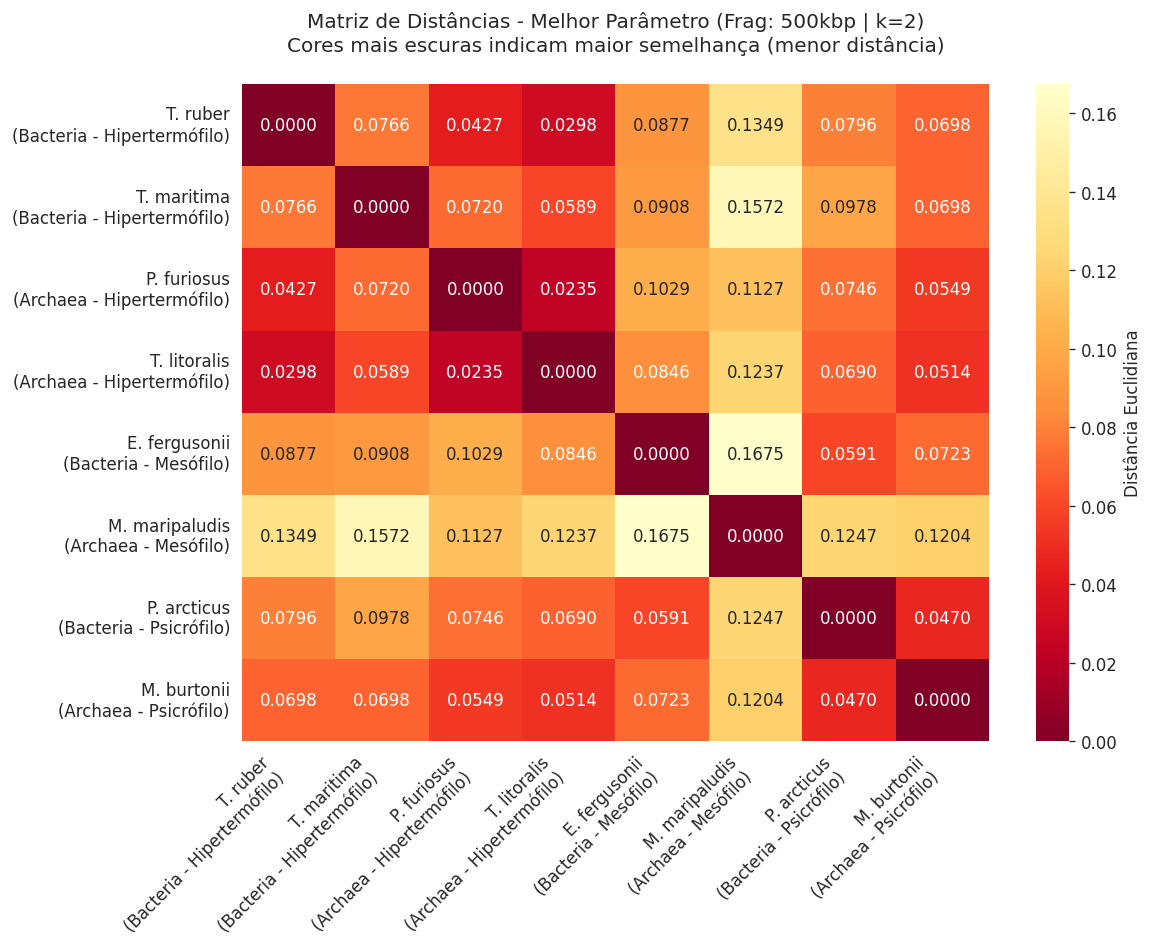


Heatmap salvo em: resultados/analise_numerica/heatmap_melhor_frag500kbp_k2.png


In [16]:
# Configurações visuais
plt.rcParams['figure.dpi'] = 120

tamanhos_frag = ["500kbp", "1000kbp", "1500kbp"]
valores_k = [1, 2, 3, 4, 5, 6, 7, 8]

resultados_metricas = []
melhor_score = float('inf')
melhor_parametro = None
melhor_matriz = None
melhor_df = None

print("Calculando distâncias para todos os parâmetros...\n")

for TAMANHO in tamanhos_frag:
    for K_VALUE in valores_k:
        csv_path = f'resultados/vetores_frag{TAMANHO}_k{K_VALUE}.csv'
        if not os.path.exists(csv_path):
            continue

        df = pd.read_csv(csv_path)

        # Isola apenas as colunas dos k-mers e normaliza para frequência relativa
        kmer_cols = df.columns[3:]
        vetores = df[kmer_cols].values
        vetores_norm = vetores / vetores.sum(axis=1, keepdims=True)

        # Calcula a matriz de distâncias Euclidianas entre todos os 8 organismos
        distancias = pdist(vetores_norm, metric='euclidean')
        matriz_dist = squareform(distancias)

        # Cria um DataFrame da matriz para facilitar a busca
        df_dist = pd.DataFrame(matriz_dist, index=df['organismo'], columns=df['organismo'])

        # Lógica da Métrica: Foco na T. ruber (Bactéria Hipertermófila)
        try:
            # 1. Distância para Archaeas do MESMO ambiente (Convergência)
            dist_env_pf = df_dist.loc['T. ruber', 'P. furiosus']
            dist_env_tl = df_dist.loc['T. ruber', 'T. litoralis']
            media_dist_ambiente = (dist_env_pf + dist_env_tl) / 2

            # 2. Distância para Bactérias de OUTROS ambientes (Taxonomia)
            dist_tax_ef = df_dist.loc['T. ruber', 'E. fergusonii'] # Mesófilo
            dist_tax_pa = df_dist.loc['T. ruber', 'P. arcticus']   # Psicrófilo
            media_dist_taxonomia = (dist_tax_ef + dist_tax_pa) / 2

            # Razão: (Distância Ambiente / Distância Taxonomia)
            # Menor que 1 significa que ela é mais parecida com as Archaeas do que com as Bactérias!
            razao = media_dist_ambiente / media_dist_taxonomia

            resultados_metricas.append({
                'Tamanho': TAMANHO,
                'K': K_VALUE,
                'Dist_Ambiente': media_dist_ambiente,
                'Dist_Taxonomia': media_dist_taxonomia,
                'Razao_Score': razao
            })

            # Guarda o melhor resultado (menor razão)
            if razao < melhor_score:
                melhor_score = razao
                melhor_parametro = (TAMANHO, K_VALUE)
                melhor_matriz = df_dist
                melhor_df = df

        except KeyError:
            # Caso algum organismo falte no CSV
            continue

# Converte resultados para DataFrame e ordena do melhor pro pior score
df_resultados = pd.DataFrame(resultados_metricas)
df_resultados = df_resultados.sort_values('Razao_Score').reset_index(drop=True)

print("RANKING DOS MELHORES PARÂMETROS (Menor Score é melhor):")
print(df_resultados.head(10).to_string())

# ==========================================
# PLOT DO HEATMAP PARA O MELHOR PARÂMETRO
# ==========================================
print(f"\nGerando Heatmap para o melhor parâmetro: {melhor_parametro[0]}, k={melhor_parametro[1]}")

# Ajustando os rótulos para mostrar "Nome (Domínio - Ambiente)" no Heatmap
rotulos = []
for org in melhor_matriz.index:
    meta = melhor_df[melhor_df['organismo'] == org].iloc[0]
    rotulos.append(f"{org}\n({meta['dominio']} - {meta['ambiente']})")

melhor_matriz.index = rotulos
melhor_matriz.columns = rotulos

plt.figure(figsize=(10, 8))
sns.heatmap(melhor_matriz, annot=True, fmt=".4f", cmap="YlOrRd_r", cbar_kws={'label': 'Distância Euclidiana'})
plt.title(f"Matriz de Distâncias - Melhor Parâmetro (Frag: {melhor_parametro[0]} | k={melhor_parametro[1]})\nCores mais escuras indicam maior semelhança (menor distância)", pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

# Salva o Heatmap
os.makedirs('resultados/analise_numerica', exist_ok=True)
caminho_heatmap = f'resultados/analise_numerica/heatmap_melhor_frag{melhor_parametro[0]}_k{melhor_parametro[1]}.png'
plt.savefig(caminho_heatmap)
plt.show()

print(f"\nHeatmap salvo em: {caminho_heatmap}")